In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits 
from sklearn.model_selection import train_test_split

rng = np.random.default_rng()

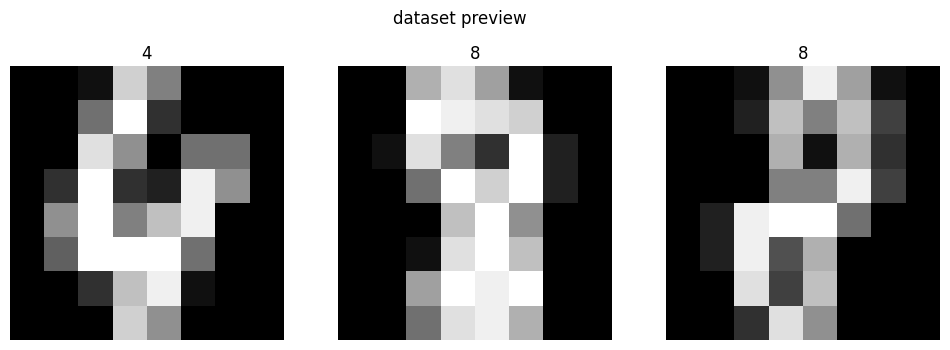

In [56]:
digits = load_digits()


"""
images are of size (1797, 8, 8)
labels are of size (1797, )

"""

images = digits.images
labels = digits.target


#dataset preview
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    x = rng.integers(low=0, high=images.shape[0])
    axes[i].imshow(images[x], cmap="gray")
    axes[i].set_title(label[x])
    axes[i].axis('off')
plt.suptitle('dataset preview')
plt.show()

In [57]:
X = images.reshape(images.shape[0], -1) # shape becomes (1797, 64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=23,
    stratify=labels  #preserves the proportion of labels in train and test split
)


In [68]:
class NearestNeighbor:  #Neighbour is not used widely lmao
    def __init__(self):
        pass

    def train(self, X, y):
        #Just memorize the dataset
        """
        X is of size (N x d) where N is the number of imagess and d is the dimension of the flattened image. for eg (32x32x3) would be a single row
        of 3072
        Y is of size (N x 1) where each row is the label for the image X[i]
        """
        self.Xtr = X
        self.ytr = y

    def predict(self, X):
        #number of images to be tested
        num_test = X.shape[0] # will return smth like (N2, d) so num_test is N2
        Ypred = np.zeros(num_test, dtype = self.ytr.dtype)

        for i in range(num_test):
            #distance matrix using distance L1
            #distance = np.sum(np.abs(self.Xtr - X[i, :]), axis = 1)
            #L2
            distance = np.sqrt(np.sum(np.square(self.Xtr - X[i, :]), axis = 1)) 
            
            min_dist = np.argmin(distance)
            Ypred[i] = self.ytr[min_dist]

        return Ypred

In [69]:
model = NearestNeighbor()
model.train(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9888888888888889
